# A/B-тест: Статистический анализ и бизнес-рекомендации

## План анализа

На основе проверок из ноутбука 02 применяем следующие методы:

| Метрика | Тест | Обоснование |
|---|---|---|
| **Conversion Rate** | Z-тест для долей | Бинарная метрика, предпосылок нет |
| **AOV (средний чек)** | Манна-Уитни | Распределение не нормальное, выбросы, тестируем медианы |
| **ADurationTime(среднее время сессии пользователей)** | t-критерий Стьюдента | Нормальное распределение для непрерыных величин |
| **Session Duration** | T-тест Стьюдента / Уэлча | Проверим предпосылки, выберем вариант |

**Поправка на множественные сравнения:** Бенджамини-Хохберг (FDR), т.к. тестируем несколько метрик одновременно.

## Критерии принятия решения

- **Статистическая значимость:** p-value < 0.05 (до поправки) или adjusted p-value < 0.05 (после поправки)
- **Практическая значимость:** эффект должен превышать MDE (минимальный детектируемый эффект), заложенный при дизайне теста
- **Guardrail метрики:** не должны деградировать (session duration не должен уменьшиться)

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/ab_test_data.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Фильтруем покупателей с валидными чеками (как в ноутбуке 02)
df_buyers = df[(df["converted"] == 1) & df["order_value"].notna()].copy()

print(f"Всего пользователей: {len(df)}")
print(f"Покупок с чеком: {len(df_buyers)}")
print()

# Подготовка данных для тестов
group_A = df[df["group"] == "A"]
group_B = df[df["group"] == "B"]

buyers_A = df_buyers[df_buyers["group"] == "A"]
buyers_B = df_buyers[df_buyers["group"] == "B"]

print(f"Группа A: {len(group_A)} пользователей, {len(buyers_A)} покупок")
print(f"Группа B: {len(group_B)} пользователей, {len(buyers_B)} покупок")

Всего пользователей: 30000
Покупок с чеком: 3212

Группа A: 15000 пользователей, 1464 покупок
Группа B: 15000 пользователей, 1748 покупок


## Тест 1: Conversion Rate (доля купивших)

**Метрика:** доля пользователей, совершивших покупку (бинарная: 0/1)

**Гипотезы:**
- H0: p_A = p_B (конверсия одинакова)
- H1: p_A ≠ p_B (конверсия различается)

**Метод:** Z-тест для двух долей (пропорций)
- Применим для бинарных данных
- Не требует предпосылок о нормальности
- Асимптотически точен при больших выборках (n > 30)

In [2]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Считаем конверсии
conv_A = group_A["converted"].sum()
conv_B = group_B["converted"].sum()

n_A = len(group_A)
n_B = len(group_B)

rate_A = conv_A / n_A
rate_B = conv_B / n_B

print(f"Конверсия группы A: {conv_A}/{n_A} = {rate_A:.4f} ({rate_A:.2%})")
print(f"Конверсия группы B: {conv_B}/{n_B} = {rate_B:.4f} ({rate_B:.2%})")
print(f"Разница: {rate_B - rate_A:.4f} ({(rate_B - rate_A):.2%})")
print()

# Z-тест
count = np.array([conv_B, conv_A])
nobs = np.array([n_B, n_A])

stat, p_value_conv = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z-статистика: {stat:.4f}")
print(f"P-value: {p_value_conv:.4f}")
print()

# Доверительный интервал для разницы долей (95%)
ci_A = proportion_confint(conv_A, n_A, alpha=0.05, method='wilson')
ci_B = proportion_confint(conv_B, n_B, alpha=0.05, method='wilson')

print(f"95% CI для конверсии A: [{ci_A[0]:.4f}, {ci_A[1]:.4f}]")
print(f"95% CI для конверсии B: [{ci_B[0]:.4f}, {ci_B[1]:.4f}]")
print()

# Интерпретация
alpha = 0.05
if p_value_conv < alpha:
    print(f" Результат статистически значим (p < {alpha})")
    print(f"   Конверсия группы B выше на {(rate_B - rate_A):.2%}")
else:
    print(f" Результат статистически незначим (p >= {alpha})")

Конверсия группы A: 1464/15000 = 0.0976 (9.76%)
Конверсия группы B: 1757/15000 = 0.1171 (11.71%)
Разница: 0.0195 (1.95%)

Z-статистика: 5.4643
P-value: 0.0000

95% CI для конверсии A: [0.0930, 0.1025]
95% CI для конверсии B: [0.1121, 0.1224]

 Результат статистически значим (p < 0.05)
   Конверсия группы B выше на 1.95%


## Тест 2: AOV (Average Order Value — средний чек)

**Метрика:** сумма заказа среди покупателей (непрерывная, скошенная)

**Гипотезы:**
- H0: распределения чеков в группах A и B одинаковы
- H1: распределения различаются

**Метод:** Манна-Уитни (Mann-Whitney U test)
- Непараметрический тест: не требует нормальности
- Тестирует разницу **медиан** (устойчив к выбросам)
- Работает через ранги, а не сами значения

In [3]:
from scipy.stats import mannwhitneyu

# Данные: чеки покупателей
checks_A = buyers_A["order_value"]
checks_B = buyers_B["order_value"]

# Медианы
median_A = checks_A.median()
median_B = checks_B.median()

print(f"Медиана чека A: {median_A:,.0f} ₽")
print(f"Медиана чека B: {median_B:,.0f} ₽")
print(f"Разница медиан: {median_B - median_A:,.0f} ₽ ({(median_B - median_A)/median_A:.1%})")
print()

# Манна-Уитни
stat, p_value_aov = mannwhitneyu(checks_B, checks_A, alternative='two-sided')
print(f"U-статистика: {stat:.2f}")
print(f"P-value: {p_value_aov:.4f}")
print()

# Средние (для сравнения — они завышены из-за «китов»)
mean_A = checks_A.mean()
mean_B = checks_B.mean()
print(f"Средний чек A: {mean_A:,.0f} ₽")
print(f"Средний чек B: {mean_B:,.0f} ₽")
print(f"Разница средних: {mean_B - mean_A:,.0f} ₽ ({(mean_B - mean_A)/mean_A:.1%})")
print()

# Интерпретация
if p_value_aov < alpha:
    print(f"Разница медиан статистически значима (p < {alpha})")
else:
    print(f"Разница медиан статистически незначима (p >= {alpha})")
    print(f"Медианы почти одинаковые: {median_A:,.0f} vs {median_B:,.0f} ₽")

Медиана чека A: 3,040 ₽
Медиана чека B: 2,990 ₽
Разница медиан: -50 ₽ (-1.7%)

U-статистика: 1243278.50
P-value: 0.1660

Средний чек A: 4,564 ₽
Средний чек B: 5,825 ₽
Разница средних: 1,261 ₽ (27.6%)

Разница медиан статистически незначима (p >= 0.05)
Медианы почти одинаковые: 3,040 vs 2,990 ₽


## Тест 3: Session Duration (среднее время сессии, guardrail)

**Метрика:** время сессии в секундах по всем пользователям

**Гипотезы:**
- H0: μ_A = μ_B (время сессии не изменилось)
- H1: μ_A ≠ μ_B

**Метод:** t-тест (Стьюдент или Уэлч по результату Левена)
- Распределение гамма-подобное, но без тяжёлых хвостов и выбросов
- n = 15 000 на группу → ЦПТ обеспечивает нормальность среднего
- Это guardrail-метрика: значимое ИЗМЕНЕНИЕ здесь — сигнал проблемы, а не успеха

In [4]:
from scipy.stats import ttest_ind, levene

# Время сессии по группам
sess_A = group_A["session_duration"].dropna()
sess_B = group_B["session_duration"].dropna()

print(f"Сессия A: n = {len(sess_A)}, mean = {sess_A.mean():.1f} c, median = {sess_A.median():.1f} c")
print(f"Сессия B: n = {len(sess_B)}, mean = {sess_B.mean():.1f} c, median = {sess_B.median():.1f} c")
print()

# Шаг 1: равенство дисперсий → выбор версии теста
stat_lev, p_lev_sess = levene(sess_A, sess_B, center='median')
equal_var = p_lev_sess >= 0.05
print(f"Левен: p = {p_lev_sess:.4f} → используем {'Стьюдента' if equal_var else 'Уэлча'}")

# Шаг 2: t-тест
t_stat, p_value_sess = ttest_ind(sess_B, sess_A, equal_var=equal_var)
print(f"t-статистика: {t_stat:.4f}")
print(f"P-value: {p_value_sess:.4f}")
print()

# Шаг 3: 95% CI разницы средних (при n = 15 000 критическое t ≈ 1.96)
se = np.sqrt(sess_A.var(ddof=1)/len(sess_A) + sess_B.var(ddof=1)/len(sess_B))
diff = sess_B.mean() - sess_A.mean()
ci_lower, ci_upper = diff - 1.96 * se, diff + 1.96 * se
print(f"95% CI разницы: [{ci_lower:.2f}, {ci_upper:.2f}] c")

if p_value_sess >= 0.05:
    print("Guardrail в порядке: фича не изменила время сессии")
else:
    print("Время сессии значимо изменилось — нужен разбор до раскатки")

Сессия A: n = 15000, mean = 179.8 c, median = 151.2 c
Сессия B: n = 15000, mean = 179.8 c, median = 151.4 c

Левен: p = 0.8453 → используем Стьюдента
t-статистика: -0.0044
P-value: 0.9965

95% CI разницы: [-2.89, 2.87] c
Guardrail в порядке: фича не изменила время сессии


## Поправка на множественные сравнения

Мы тестируем **3 метрики** одновременно (Conversion, AOV, ARPU). Без поправки
вероятность хотя бы одной ложноположительной находки растёт:

P(хотя бы одна ошибка) = 1 − (1 − 0.05)³ ≈ 14.3%

**Метод:** Бенджамини-Хохберг (False Discovery Rate, FDR)
- Контролирует долю ложных открытий среди всех отвергнутых H0
- Мягче Бонферрони (который делит alpha на число тестов)
- Стандарт в продуктовой аналитике (Яндекс, Авито, Тинькофф)

In [5]:
p_values = [p_value_conv, p_value_aov, p_value_sess]
test_names = ["Conversion Rate", "AOV (Манна-Уитни)", "Session Duration (t-тест)"]

reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"{'Метрика':<28} {'P-value':<10} {'Adj. P-value':<15} {'Значим?':<10}")
print("-" * 65)
for name, p, p_adj, rej in zip(test_names, p_values, p_adjusted, reject):
    print(f"{name:<28} {p:<10.4f} {p_adj:<15.4f} {'Да' if rej else 'Нет':<10}")

Метрика                      P-value    Adj. P-value    Значим?   
-----------------------------------------------------------------
Conversion Rate              0.0000     0.0000          Да        
AOV (Манна-Уитни)            0.1660     0.2490          Нет       
Session Duration (t-тест)    0.9965     0.9965          Нет       


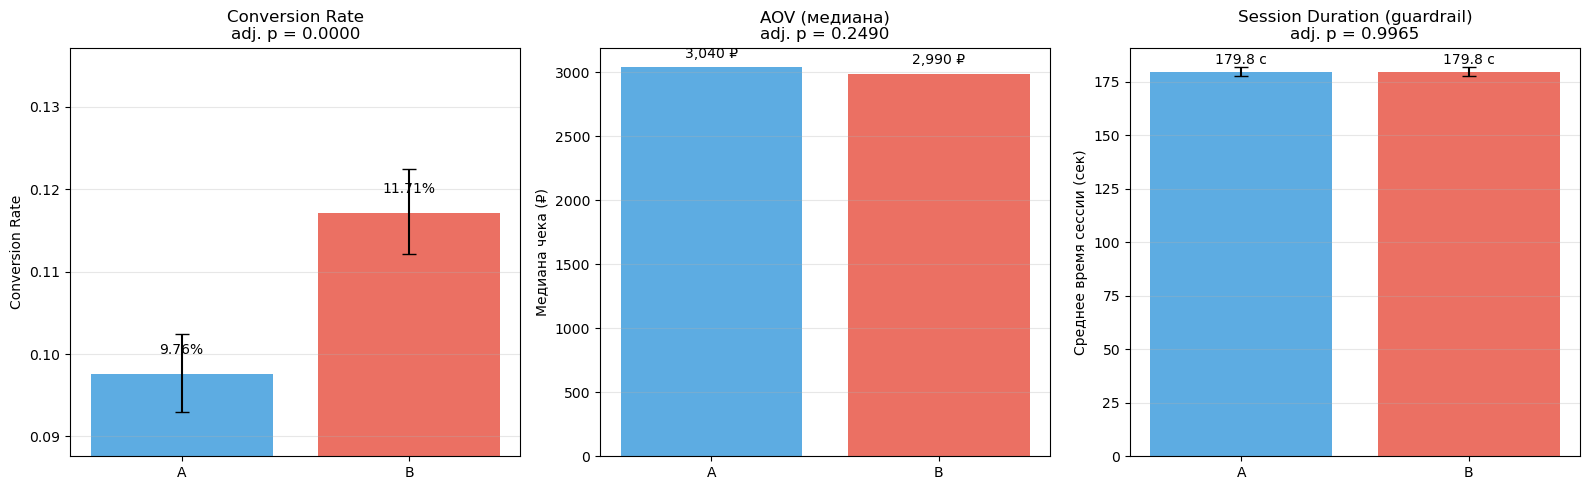

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Панель 1: Conversion Rate (столбцы + Wilson CI) ──
rates = [rate_A, rate_B]
yerr_conv = [
    [rate_A - ci_A[0], rate_B - ci_B[0]],   # нижние усы
    [ci_A[1] - rate_A, ci_B[1] - rate_B]    # верхние усы
]
axes[0].bar(['A', 'B'], rates, yerr=yerr_conv, capsize=5,
            color=['#3498db', '#e74c3c'], alpha=0.8)
axes[0].set_ylabel('Conversion Rate')
axes[0].set_title(f'Conversion Rate\nadj. p = {p_adjusted[0]:.4f}', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([min(rates) - 0.01, max(rates) + 0.02])
for i, r in enumerate(rates):
    axes[0].text(i, r + 0.002, f'{r:.2%}', ha='center', va='bottom')

# ── Панель 2: AOV (медианы, без усов — Манна-Уитни даёт p, а не CI) ──
medians = [median_A, median_B]
axes[1].bar(['A', 'B'], medians, color=['#3498db', '#e74c3c'], alpha=0.8)
axes[1].set_ylabel('Медиана чека (₽)')
axes[1].set_title(f'AOV (медиана)\nadj. p = {p_adjusted[1]:.4f}', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, m in enumerate(medians):
    axes[1].text(i, m + 50, f'{m:,.0f} ₽', ha='center', va='bottom')

# ── Панель 3: Session Duration (средние + 95% CI из t-теста) ──
sess_means = [sess_A.mean(), sess_B.mean()]
se_A = sess_A.std(ddof=1) / np.sqrt(len(sess_A))   # стандартная ошибка среднего A
se_B = sess_B.std(ddof=1) / np.sqrt(len(sess_B))   # стандартная ошибка среднего B
yerr_sess = [
    [1.96 * se_A, 1.96 * se_B],   # вниз от столбца
    [1.96 * se_A, 1.96 * se_B]    # вверх от столбца (CI симметричный)
]
axes[2].bar(['A', 'B'], sess_means, yerr=yerr_sess, capsize=5,
            color=['#3498db', '#e74c3c'], alpha=0.8)
axes[2].set_ylabel('Среднее время сессии (сек)')
axes[2].set_title(f'Session Duration (guardrail)\nadj. p = {p_adjusted[2]:.4f}', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, s in enumerate(sess_means):
    axes[2].text(i, s + 2, f'{s:.1f} c', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path
IMG = Path("../images")
IMG.mkdir(exist_ok=True)

fig.savefig(IMG / "results_summary.png", dpi=150, bbox_inches="tight")
print(f"Сохранено: {IMG.resolve() / 'results_summary.png'}")

Сохранено: C:\Users\777\Desktop\a-b test project\images\results_summary.png
